# Figure 2E/F encoding-analysis inspection

Goal:
- Fix notebook path setup so it works from either the project root or `notebooks/`.
- Compare the released `.pkl` dataset files with the precomputed `.mat` GLM/PVAF outputs.
- Use `.mat` files as a validation and analysis-output source before rebuilding the full GLM from scratch.

In [2]:
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import get_data_dir, get_source_data_path
from src.file_utils import build_file_inventory
from src.load_data import inspect_object, load_pickle

DATA_DIR = get_data_dir()
SOURCE_DATA_PATH = get_source_data_path()

print("project root:", PROJECT_ROOT)
print("data dir:", DATA_DIR)
print("source data:", SOURCE_DATA_PATH)
print("data dir exists:", DATA_DIR.exists())

project root: c:\Users\ksbong\Documents\GitHub\dmfc-pong-reconstruction
data dir: c:\Users\ksbong\Documents\GitHub\dmfc-pong-reconstruction\data\external\data
source data: c:\Users\ksbong\Documents\GitHub\dmfc-pong-reconstruction\data\external\data\Source_Data.xlsx
data dir exists: True


In [3]:
files_df = build_file_inventory(DATA_DIR, project_root=PROJECT_ROOT)

files_df.loc[
    files_df["name"].str.contains("glm|PVAF|dmfc_dataset|Source_Data", case=False, regex=True),
    ["name", "suffix", "size_mb", "load_policy", "relative_path"],
]

,name,suffix,size_mb,load_policy,relative_path
1,all_hand_dmfc_dataset_50ms.pkl,.pkl,1202.042446,very_large,data\external\data\all_hand_dmfc_dataset_50ms.pkl
0,all_hand_dmfc_dataset_50ms.mat,.mat,1110.181453,very_large,data\external\data\all_hand_dmfc_dataset_50ms.mat
14,perle_hand_dmfc_dataset_50ms.pkl,.pkl,1023.795490,very_large,data\external\data\perle_hand_dmfc_dataset_50m...
13,perle_hand_dmfc_dataset_50ms.mat,.mat,940.456131,very_large,data\external\data\perle_hand_dmfc_dataset_50m...
19,run_glm_egocentric_ball.mat,.mat,520.880001,very_large,data\external\data\run_glm_egocentric_ball.mat
18,run_glm.mat,.mat,520.084643,very_large,data\external\data\run_glm.mat
7,mahler_hand_dmfc_dataset_50ms.pkl,.pkl,228.117346,large,data\external\data\mahler_hand_dmfc_dataset_50...
6,mahler_hand_dmfc_dataset_50ms.mat,.mat,221.354446,large,data\external\data\mahler_hand_dmfc_dataset_50...
20,Source_Data.xlsx,.xlsx,3.364403,safe,data\external\data\Source_Data.xlsx
15,PVAF_allocentric.mat,.mat,0.197671,safe,data\external\data\PVAF_allocentric.mat


## 1. `.pkl`: raw-ish dataset objects

Use `.pkl` when you want the condition/time/neuron arrays and behavioral variables. This is the right source for learning how the analysis is constructed.

For Figure 2E/F, the important pieces are:
- `neural_responses` or `neural_responses_reliable`: firing-rate arrays, usually `[neuron, condition, time]`
- `behavioral_responses`: ball, eye, hand variables over condition/time
- `masks`: visible/occluded epoch sample selection
- `neural_idx_global`: mapping between epoch-specific neuron rows and global neuron IDs

In [4]:
dmfc = load_pickle(DATA_DIR / "all_hand_dmfc_dataset_50ms.pkl")

inspect_object(dmfc)
print("\nbehavioral epochs:", dmfc["behavioral_responses"].keys())
print("neural response keys:", dmfc["neural_responses"].keys())
print("reliable neural response keys:", dmfc["neural_responses_reliable"].keys())
print("mask keys:", dmfc["masks"].keys())

print("\nneural_responses.vis:", dmfc["neural_responses"]["vis"].shape)
print("neural_responses.occ:", dmfc["neural_responses"]["occ"].shape)
print("behavior vis ball x:", dmfc["behavioral_responses"]["vis"]["ball_pos_x_TRUE"].shape)
print("visible mask:", dmfc["masks"]["vis"]["start_occ_pad0"].shape)
print("occluded mask:", dmfc["masks"]["occ"]["occ_end_pad0"].shape)

type: <class 'dict'>
num keys: 25
first keys: ['trial_meta', 'neural_meta', 'neural_responses', 'neural_responses_sh1', 'neural_responses_sh2', 'behavioral_responses', 'masks', 'ntr_vis', 'ntr_occ', 'meta', 'neural_idx_global', 'conds_ch_dict', 'reliable_neural_idx', 'neural_responses_reliable', 'neural_responses_reliable_sh1', 'neural_responses_reliable_sh2', 'neural_responses_reliable_FactorAnalysis_10', 'neural_responses_reliable_FactorAnalysis_10_sh1', 'neural_responses_reliable_FactorAnalysis_10_sh2', 'neural_responses_reliable_FactorAnalysis_20']

behavioral epochs: dict_keys(['occ', 'vis'])
neural response keys: dict_keys(['occ', 'vis'])
reliable neural response keys: dict_keys(['occ'])
mask keys: dict_keys(['occ', 'vis'])

neural_responses.vis: (1385, 79, 100)
neural_responses.occ: (2576, 79, 100)
behavior vis ball x: (79, 100)
visible mask: (79, 100)
occluded mask: (79, 100)


## 2. `.mat`: precomputed GLM / variance-partition outputs

Use `.mat` when the original authors already saved an expensive analysis result. This is not automatically "better" than `.pkl`; it is a different layer.

- `.pkl`: better for rebuilding the analysis from data.
- `.mat`: better for checking the original MATLAB analysis outputs and validating your Python reconstruction.

Rule of thumb for this project: start from `.mat` to understand the expected shapes and results, then use `.pkl` to rebuild selected pieces.

In [5]:
import numpy as np
import pandas as pd
from scipy.io import loadmat, whosmat

pvaf_path = DATA_DIR / "PVAF_allocentric.mat"

print("Variables in PVAF_allocentric.mat:")
for name, shape, dtype in whosmat(pvaf_path):
    print(name, shape, dtype)

pvaf_mat = loadmat(pvaf_path, squeeze_me=True)
PVAF_vis = pvaf_mat["PVAF_vis3"]
PVAF_occ = pvaf_mat["PVAF_occ3"]

print("\nPVAF_vis:", PVAF_vis.shape)
print("PVAF_occ:", PVAF_occ.shape)

pvaf_summary = pd.DataFrame({
    "component": np.arange(1, PVAF_vis.shape[1] + 1),
    "visible_mean": np.nanmean(PVAF_vis, axis=0),
    "visible_sem": np.nanstd(PVAF_vis, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(PVAF_vis), axis=0)),
    "occluded_mean": np.nanmean(PVAF_occ, axis=0),
    "occluded_sem": np.nanstd(PVAF_occ, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(PVAF_occ), axis=0)),
})

pvaf_summary

Variables in PVAF_allocentric.mat:
PVAF_occ3 (2576, 7) double
PVAF_vis3 (1385, 7) double

PVAF_vis: (1385, 7)
PVAF_occ: (2576, 7)


,component,visible_mean,visible_sem,occluded_mean,occluded_sem
0,1,0.021888,0.001004,0.024599,0.000857
1,2,0.010594,0.000778,0.011682,0.000622
2,3,0.003062,0.000317,0.009134,0.000516
3,4,0.012953,0.000928,0.045070,0.001717
4,5,0.005030,0.000370,0.008648,0.000441
5,6,0.003357,0.000346,0.005403,0.000397
6,7,-0.004435,0.000639,-0.003085,0.000814


The 7 columns above are the Figure 2F variance-partition components. Do not label them by guesswork. Match them against the `Figure 2F` sheet in `Source_Data.xlsx` and the MATLAB variance-partitioning code before assigning names like ball-only, eye-only, hand-only, or shared terms.

In [6]:
glm_path = DATA_DIR / "run_glm.mat"

# These files are large. Load only the variables you need.
glm_vars = loadmat(
    glm_path,
    variable_names=["PVAF_model_vis", "PVAF_model_occ", "LL_vis", "LL_occ"],
    squeeze_me=True,
)

for key, value in glm_vars.items():
    if not key.startswith("__"):
        arr = np.asarray(value)
        print(key, arr.shape, "finite fraction:", np.isfinite(arr).mean())

LL_vis (1385, 13) finite fraction: 0.9985004165509581
LL_occ (2576, 13) finite fraction: 0.9994923554706163
PVAF_model_vis (1385, 11) finite fraction: 1.0
PVAF_model_occ (2576, 11) finite fraction: 1.0


In [10]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, whosmat

source_xlsx = SOURCE_DATA_PATH

print("Source data path:", source_xlsx)
print("exists:", source_xlsx.exists())

xlsx = pd.ExcelFile(source_xlsx)


Source data path: c:\Users\ksbong\Documents\GitHub\dmfc-pong-reconstruction\data\external\data\Source_Data.xlsx
exists: True


In [13]:
fig2_sheets = [
    s for s in xlsx.sheet_names
    if re.search(r"fig|figure|2", s, flags=re.IGNORECASE)
]

for sheet in fig2_sheets:
    
    if sheet == "Figure 2E":
        print("\n" + "=" * 80)
        print(sheet)
        
        try:
            df = pd.read_excel(source_xlsx, sheet_name=sheet)
            print(df.shape)
            display(df.head())
        except Exception as e:
            print("failed:", e)


Figure 2E
(2064, 22)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Figure 2E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,histogram (right panel),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,visible,X (% variance explained),NaN,-10.5826,-5.6009,-0.6191,4.3626,9.3443,14.326,19.3077,...,34.2528,39.2345,44.2163,49.198,54.1797,59.1614,64.1431,69.1248,74.1065,79.0882


In [14]:
pvaf_path = DATA_DIR / "PVAF_allocentric.mat"

pvaf_mat = loadmat(pvaf_path, squeeze_me=True)

PVAF_vis = np.asarray(pvaf_mat["PVAF_vis3"], dtype=float)
PVAF_occ = np.asarray(pvaf_mat["PVAF_occ3"], dtype=float)

print("PVAF_vis:", PVAF_vis.shape)
print("PVAF_occ:", PVAF_occ.shape)

print("visible finite:", np.isfinite(PVAF_vis).mean())
print("occluded finite:", np.isfinite(PVAF_occ).mean())

pd.DataFrame({
    "component": np.arange(PVAF_vis.shape[1]),
    "vis_mean": np.nanmean(PVAF_vis, axis=0),
    "vis_sem": np.nanstd(PVAF_vis, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(PVAF_vis), axis=0)),
    "occ_mean": np.nanmean(PVAF_occ, axis=0),
    "occ_sem": np.nanstd(PVAF_occ, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(PVAF_occ), axis=0)),
})

PVAF_vis: (1385, 7)
PVAF_occ: (2576, 7)
visible finite: 1.0
occluded finite: 1.0


,component,vis_mean,vis_sem,occ_mean,occ_sem
0,0,0.021888,0.001004,0.024599,0.000857
1,1,0.010594,0.000778,0.011682,0.000622
2,2,0.003062,0.000317,0.009134,0.000516
3,3,0.012953,0.000928,0.045070,0.001717
4,4,0.005030,0.000370,0.008648,0.000441
5,5,0.003357,0.000346,0.005403,0.000397
6,6,-0.004435,0.000639,-0.003085,0.000814


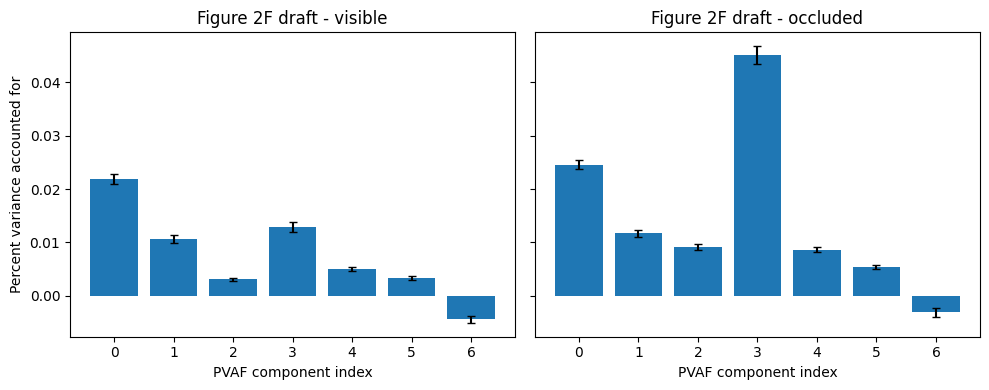

In [15]:
def mean_sem(arr):
    arr = np.asarray(arr, dtype=float)
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(arr), axis=0))
    return mean, sem


vis_mean, vis_sem = mean_sem(PVAF_vis)
occ_mean, occ_sem = mean_sem(PVAF_occ)

components = np.arange(PVAF_vis.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(components, vis_mean, yerr=vis_sem, capsize=3)
axes[0].set_title("Figure 2F draft - visible")
axes[0].set_xlabel("PVAF component index")
axes[0].set_ylabel("Percent variance accounted for")

axes[1].bar(components, occ_mean, yerr=occ_sem, capsize=3)
axes[1].set_title("Figure 2F draft - occluded")
axes[1].set_xlabel("PVAF component index")

plt.tight_layout()
plt.show()

In [ ]:
fig2e_raw = pd.read_excel(
    SOURCE_DATA_PATH,
    sheet_name="Figure 2E",
    header=None,
)

print(fig2e_raw.shape)
display(fig2e_raw.head(30))

(2065, 22)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Figure 2E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,histogram (right panel),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,visible,X (% variance explained),NaN,-10.5826,-5.6009,-0.6191,4.3626,9.3443,14.3260,19.3077,...,34.2528,39.2345,44.2163,49.1980,54.1797,59.1614,64.1431,69.1248,74.1065,79.0882
6,NaN,Y (# neurons),NaN,3,90,613.0000,381.0000,138.0000,65.0000,44.0000,...,8.0000,5.0000,2.0000,4.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
7,NaN,mean(% variance explained),NaN,5.2449,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,occluded,X (% variance explained),NaN,-8.0917,-3.11,1.8717,6.8534,11.8351,16.8168,21.7986,...,36.7437,41.7254,46.7071,51.6888,56.6705,61.6522,66.6340,71.6157,76.5974,81.5791
9,NaN,Y (# neurons),NaN,11,191,749.0000,596.0000,332.0000,202.0000,NaN,...,48.0000,39.0000,38.0000,25.0000,14.0000,13.0000,6.0000,8.0000,6.0000,2.0000


In [20]:
fig2f_df = pd.read_excel(SOURCE_DATA_PATH, sheet_name="Figure 2F")

print(fig2f_df.shape)
print(fig2f_df.columns)
display(fig2f_df.head(20))

(49, 1391)
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 1381', 'Unnamed: 1382', 'Unnamed: 1383', 'Unnamed: 1384',
       'Unnamed: 1385', 'Unnamed: 1386', 'Unnamed: 1387', 'Unnamed: 1388',
       'Unnamed: 1389', 'Unnamed: 1390'],
      dtype='object', length=1391)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 1381,Unnamed: 1382,Unnamed: 1383,Unnamed: 1384,Unnamed: 1385,Unnamed: 1386,Unnamed: 1387,Unnamed: 1388,Unnamed: 1389,Unnamed: 1390
0,Figure 2F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,visible epoch (left),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ball,mean,2.190000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,SEM,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,individual data for swarmplot,6.853951,0.171469,9.264728,-2.554802,-1.020643,-1.089197,3.704389,7.024041,...,0.210320,0.965592,0.751589,-1.109709,-0.005678,-0.545345,NaN,NaN,NaN,NaN
7,eye,mean,1.060000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,SEM,0.080000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,individual data for swarmplot,0.281157,0.403964,1.276584,0.045437,1.747241,1.992207,0.688492,1.073392,...,-0.679963,-0.960368,-0.004496,0.256355,0.983698,0.513922,NaN,NaN,NaN,NaN


# Fig 2E 모범답안

In [ ]:
def print_matching_rows(df, patterns):
    for i, row in df.iterrows():
        values = [str(v) for v in row.dropna().tolist()]
        joined = " | ".join(values)

        if any(p.lower() in joined.lower() for p in patterns):
            print(f"[row {i}] {joined[:500]}")


print_matching_rows(
    fig2e_raw,
    patterns=[
        "histogram",
        "right panel",
        "left panel",
        "visible",
        "occluded",
        "pred",
        "actual",
        "spike",
        "firing",
        "model",
    ],
)

[row 3] histogram (right panel)
[row 5] visible | X (% variance explained) | -10.5826 | -5.6009 | -0.6191 | 4.3626 | 9.3443 | 14.326 | 19.3077 | 24.2894 | 29.2711 | 34.2528 | 39.2345 | 44.2163 | 49.198 | 54.1797 | 59.1614 | 64.1431 | 69.1248 | 74.1065 | 79.0882
[row 8] occluded | X (% variance explained) | -8.0917 | -3.11 | 1.8717 | 6.8534 | 11.8351 | 16.8168 | 21.7986 | 26.7803 | 31.762 | 36.7437 | 41.7254 | 46.7071 | 51.6888 | 56.6705 | 61.6522 | 66.634 | 71.6157 | 76.5974 | 81.5791
[row 12] example neuron (left panel)
[row 14] visible | occluded
[row 15] true spike rate | predicted spike rate | true spike rate | predicted spike rate


In [ ]:
def row_numeric_values(row, start_col=2):
    values = pd.to_numeric(row.iloc[start_col:], errors="coerce").to_numpy(dtype=float)
    return values[np.isfinite(values)]


def find_row(df, col0_contains=None, col1_contains=None, start=0):
    for i in range(start, len(df)):
        c0 = str(df.iloc[i, 0]).lower()
        c1 = str(df.iloc[i, 1]).lower()

        ok0 = True if col0_contains is None else col0_contains.lower() in c0
        ok1 = True if col1_contains is None else col1_contains.lower() in c1

        if ok0 and ok1:
            return i

    raise ValueError(f"row not found: col0={col0_contains}, col1={col1_contains}")


hist_anchor = find_row(fig2e_raw, col0_contains="histogram")
print("histogram anchor row:", hist_anchor)

vis_x_row = find_row(
    fig2e_raw,
    col0_contains="visible",
    col1_contains="x",
    start=hist_anchor,
)

occ_x_row = find_row(
    fig2e_raw,
    col0_contains="occluded",
    col1_contains="x",
    start=hist_anchor,
)

print("vis_x_row:", vis_x_row)
print("occ_x_row:", occ_x_row)

vis_y_row = vis_x_row + 1
occ_y_row = occ_x_row + 1

x_vis = row_numeric_values(fig2e_raw.iloc[vis_x_row], start_col=2)
y_vis = row_numeric_values(fig2e_raw.iloc[vis_y_row], start_col=2)

x_occ = row_numeric_values(fig2e_raw.iloc[occ_x_row], start_col=2)
y_occ = row_numeric_values(fig2e_raw.iloc[occ_y_row], start_col=2)

print("visible:", x_vis.shape, y_vis.shape)
print("occluded:", x_occ.shape, y_occ.shape)

print("visible x[:5]:", x_vis[:5])
print("visible y[:5]:", y_vis[:5])
print("occluded x[:5]:", x_occ[:5])
print("occluded y[:5]:", y_occ[:5])

histogram anchor row: 3
vis_x_row: 5
occ_x_row: 8
visible: (19,) (19,)
occluded: (19,) (18,)
visible x[:5]: [-10.5826  -5.6009  -0.6191   4.3626   9.3443]
visible y[:5]: [  3.  90. 613. 381. 138.]
occluded x[:5]: [-8.0917 -3.11    1.8717  6.8534 11.8351]
occluded y[:5]: [ 11. 191. 749. 596. 332.]


In [28]:
def align_histogram_xy(x, y, label=""):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    print(f"{label} before:", x.shape, y.shape)

    # Case 1: x is bin edges, y is bin counts/density
    if len(x) == len(y) + 1:
        x = (x[:-1] + x[1:]) / 2
        print(f"{label}: converted x bin edges to bin centers")

    # Case 2: already aligned
    elif len(x) == len(y):
        print(f"{label}: already aligned")

    # Case 3: something else is wrong
    else:
        print(f"{label}: unexpected mismatch")
        print("x:", x)
        print("y:", y)
        raise ValueError(
            f"{label}: x and y length mismatch after cleaning: "
            f"x={len(x)}, y={len(y)}"
        )

    print(f"{label} after:", x.shape, y.shape)
    return x, y


x_vis_aligned, y_vis_aligned = align_histogram_xy(x_vis, y_vis, label="visible")
x_occ_aligned, y_occ_aligned = align_histogram_xy(x_occ, y_occ, label="occluded")

visible before: (19,) (19,)
visible: already aligned
visible after: (19,) (19,)
occluded before: (19,) (18,)
occluded: converted x bin edges to bin centers
occluded after: (18,) (18,)


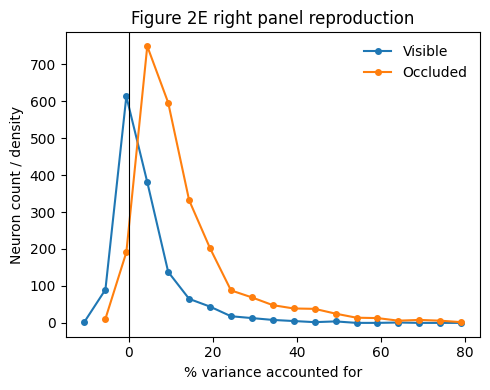

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(
    x_vis_aligned,
    y_vis_aligned,
    marker="o",
    linewidth=1.5,
    markersize=4,
    label="Visible",
)

ax.plot(
    x_occ_aligned,
    y_occ_aligned,
    marker="o",
    linewidth=1.5,
    markersize=4,
    label="Occluded",
)

ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("% variance accounted for")
ax.set_ylabel("Neuron count / density")
ax.set_title("Figure 2E right panel reproduction")
ax.legend(frameon=False)

plt.tight_layout()

# fig2e_right_path = FIGURE_DIR / "fig2e_right_histogram_finaldata.png"
# fig.savefig(fig2e_right_path, dpi=300, bbox_inches="tight")
# print("saved:", fig2e_right_path)

plt.show()